# Stripe Subscriptions Upsell — Empirical Conversion Analysis

**Goal:** Identify non-Subscription merchants with the highest likelihood of converting to Stripe Subscriptions, and create a  targeted list for a sales/marketing campaign.

**Approach:** Empirical holdout analysis — we use observed behavior in a 7-month window to characterize merchants, then measure who actually adopted Subscriptions in the following 7-month window. The equal split strikes a good balance between getting a solid number of merchants in the observation period but also leaving enough time in the conversion window to get a good number of converters, yielding better confidence in our results.

| Window | Period | Purpose |
|---|---|---|
| Observation Window | May 2041 – Nov 2041 (7 months) | Characterize merchant behavior |
| Conversion Window | Dec 2041 – Jun 2042 (7 months) | Measure who adopted Subscriptions |

## 0. Setup
Setup duckdb and load our 2 datasets

In [1]:
  import pandas as pd
  import matplotlib.pyplot as plt 
  import matplotlib.ticker as mtick
  pd.set_option('display.max_rows', 100) #will allow us to inspect the data more easily

In [2]:
#%load_ext sql
%reload_ext sql
%sql duckdb://
%config SqlMagic.autopandas = True
%config SqlMagic.feedback = False
%config SqlMagic.displaycon = False
%config SqlMagic.displaylimit = 200 

Connecting to 'duckdb://'

In [3]:
%%sql
CREATE OR REPLACE VIEW merchants AS
    SELECT * from read_csv_auto('merchants.csv');

CREATE OR REPLACE VIEW payments AS
    SELECT * FROM read_csv_auto('payments.csv.csv');

,Success


In [4]:
%%sql
SELECT * FROM (DESCRIBE merchants)

,column_name,column_type,null,key,default,extra
0,merchant,VARCHAR,YES,None,None,None
1,industry,VARCHAR,YES,None,None,None
2,first_charge_date,VARCHAR,YES,None,None,None
3,country,VARCHAR,YES,None,None,None
4,business_size,VARCHAR,YES,None,None,None


In [5]:
%%sql
SELECT * FROM (DESCRIBE payments)

,column_name,column_type,null,key,default,extra
0,date,TIMESTAMP WITH TIME ZONE,YES,None,None,None
1,merchant,VARCHAR,YES,None,None,None
2,subscription_volume,BIGINT,YES,None,None,None
3,checkout_volume,BIGINT,YES,None,None,None
4,payment_link_volume,BIGINT,YES,None,None,None
5,total_volume,BIGINT,YES,None,None,None


## Data Inspection
Here we inspect our categorical columns to find malformed values that we need to deal with.

In [6]:
%%sql                                                                                                                                                                                                              
  WITH base AS (                                                                                                                                                                                                     
      SELECT 'first_charge_date' AS field, first_charge_date AS value, COUNT(*) AS n                                                                                                                                 
      FROM merchants                          
      WHERE first_charge_date IS NULL OR NOT regexp_matches(first_charge_date, '^\d{4}-')                                                                                                                            
      GROUP BY first_charge_date                                                                                                                                                                                     
                                                                                                                                                                                                                     
      UNION ALL                                                                                                                                                                                                    
                                                                                                                                                                                                                     
      SELECT 'industry', industry, COUNT(*)                                                                                                                                                                        
      FROM merchants                      
      GROUP BY industry
                                                                                                                                                                                                                     
      UNION ALL
                                                                                                                                                                                                                     
      SELECT 'business_size', business_size, COUNT(*)                                                                                                                                                              
      FROM merchants
      GROUP BY business_size

      UNION ALL

      SELECT 'country', country, COUNT(*)     
      FROM merchants                      
      GROUP BY country
  ),                                                                                                                                                                                                                 
  ranked AS (
      SELECT *, ROW_NUMBER() OVER (PARTITION BY field ORDER BY n DESC) AS rn                                                                                                                                         
      FROM base                                                                                                                                                                                                    
  )                                           
  SELECT field, value, n                  
  FROM ranked
  --WHERE rn <= 10                                                                                                                                                                                                      
  ORDER BY field, n DESC

,field,value,n
0,business_size,small,22853
1,business_size,medium,622
2,business_size,large,152
3,country,US,8595
4,country,GB,3478
5,country,FR,1700
6,country,AU,1378
7,country,CA,1324
8,country,ES,926
9,country,IT,821



### Duplicates

Lets check for duplicates in the primary keys where there shouldnt be any. For payments, the combination of dayXmerchant should be unique. There appears to be an issue with some scientific notation strings in the merchant ids, likely from excel/google sheets automatically converting them. These values cannot be recovered so we must exclude those records in our **Merchants Monthly** table.

In [7]:
%%sql                                                                                                                                                                                                              
  SELECT merchant, COUNT(*) AS n                                                                                                                                                                                     
  FROM merchants                                                                                                                                                                                                     
  GROUP BY merchant                                                                                                                                                                                                  
  HAVING COUNT(*) > 1                                                                                                                                                                                                

  UNION ALL                                                                                                                                                                                                          
                                                                                                                                                                                                                     
  SELECT merchant || ' / ' || CAST(date AS VARCHAR), COUNT(*)                                                                                                                                                        
  FROM payments                                                   
  GROUP BY merchant, date
  HAVING COUNT(*) > 1 

,merchant,n
0,0.00E+0,8
1,4.72E+10,2
2,0.00E+00 / 2042-03-09 18:00:00-06,2
3,0.00E+00 / 2041-12-15 18:00:00-06,2
4,0.00E+00 / 2042-04-19 18:00:00-06,2
5,0.00E+00 / 2042-05-21 18:00:00-06,2
6,0.00E+00 / 2042-06-18 18:00:00-06,3
7,0.00E+00 / 2042-04-11 18:00:00-06,2
8,0.00E+00 / 2041-12-14 18:00:00-06,2
9,4.72E+10 / 2042-03-15 18:00:00-06,2


### Numerical Values
Lets check for issues in our numerical columns. 
No negatives, minimums are zero which is expected, and the ranges are plausible.

In [8]:
%%sql                                                                                                                                                                                                              
  SELECT                                                                                                                                                                                                             
      MIN(subscription_volume)    AS sub_min,                                                                                                                                                                        
      MAX(subscription_volume)    AS sub_max,                                                                                                                                                                        
      AVG(subscription_volume)    AS sub_avg,                                                                                                                                                                        
      MIN(checkout_volume)        AS co_min,                                                                                                                                                                         
      MAX(checkout_volume)        AS co_max,                                                                                                                                                                         
      AVG(checkout_volume)        AS co_avg,                                                                                                                                                                         
      MIN(payment_link_volume)    AS pl_min,
      MAX(payment_link_volume)    AS pl_max,                                                                                                                                                                         
      AVG(payment_link_volume)    AS pl_avg,                                                                                                                                                                         
      MIN(total_volume)           AS total_min,
      MAX(total_volume)           AS total_max,                                                                                                                                                                      
      AVG(total_volume)           AS total_avg                    
  FROM payments

,sub_min,sub_max,sub_avg,co_min,co_max,co_avg,pl_min,pl_max,pl_avg,total_min,total_max,total_avg
0,0,108387903,39247.66385,0,34259069,11013.756243,0,11829000,1843.901044,1,2243810482,358291.355243


Heres a summary of nulls/malformed values

In [9]:
%%sql                                                                                                                                                                                                              
  SELECT 'merchants' AS source, 'merchant' AS field,                                                                                                                                                                 
      COUNT(*) AS total,                                                                                                                                                                                             
      SUM(CASE WHEN merchant IS NULL THEN 1 ELSE 0 END) AS nulls,                                                                                                                                                    
      SUM(CASE WHEN regexp_matches(merchant, '[eE][+-][0-9]') THEN 1 ELSE 0 END) AS malformed                                                                                                                        
  FROM merchants                                                                                                                                                                                                     
                                                                                                                                                                                                                     
  UNION ALL                                                                                                                                                                                                          
                                                                                                                                                                                                                     
  SELECT 'merchants', 'first_charge_date',                                                                                                                                                                           
      COUNT(*),                                                                                                                                                                                                      
      SUM(CASE WHEN first_charge_date IS NULL OR first_charge_date = '0' THEN 1 ELSE 0 END),                                                                                                                       
      SUM(CASE WHEN TRY_CAST(first_charge_date AS TIMESTAMPTZ) IS NULL
                AND first_charge_date != '0' THEN 1 ELSE 0 END)
  FROM merchants                                                                                                                                                                                                     
                                          
  UNION ALL                                                                                                                                                                                                          
                                                                                                                                                                                                                     
  SELECT 'merchants', 'industry',                                                                                                                                                                                    
      COUNT(*),                                                                                                                                                                                                      
      SUM(CASE WHEN industry IS NULL OR industry = '0' THEN 1 ELSE 0 END),                                                                                                                                         
      0                                       
  FROM merchants                          

  UNION ALL                                                                                                                                                                                                          
   
  SELECT 'payments', 'merchant',                                                                                                                                                                                     
      COUNT(*),                                                                                                                                                                                                    
      SUM(CASE WHEN merchant IS NULL THEN 1 ELSE 0 END),
      SUM(CASE WHEN regexp_matches(merchant, '[eE][+-][0-9]') THEN 1 ELSE 0 END)
  FROM payments                              
                                                                                                                                                                                                                                                                                                                                                                                                                                         

,source,field,total,nulls,malformed
0,merchants,merchant,23627,0.0,129.0
1,merchants,first_charge_date,23627,26.0,0.0
2,merchants,industry,23627,7.0,0.0
3,payments,merchant,1577887,0.0,8966.0


## Data Cleaning
Lets clean our base tables now so we dont have to clean in multiple places downstream.
0s get turned to nulls and 

In [10]:
%%sql                                                                                                                                                                                                                                                                                                                                                                                                            
CREATE OR REPLACE VIEW merchants AS
          SELECT
              merchant,
              NULLIF(industry, '0')                                         AS industry,
              TRY_CAST(TRY_CAST(first_charge_date AS TIMESTAMPTZ) AS DATE) AS first_charge_date,
              country,
              business_size
          FROM read_csv_auto('merchants.csv')
          WHERE NULLIF(merchant, '') IS NOT NULL --exclude nulls
            AND NOT regexp_matches(merchant, '[eE][+-][0-9]'); --exclude malformed ids

      CREATE OR REPLACE VIEW payments AS
          SELECT *
          FROM read_csv('payments.csv.csv', types={'merchant': 'VARCHAR'})
          WHERE NULLIF(merchant, '') IS NOT NULL --exclude nulls
            AND NOT regexp_matches(merchant, '[eE][+-][0-9]'); --exclude malformed ids

,Success


## 1. Build the Analytical Base

We construct a clean merchant-level table from the raw payments data. The pipeline has three steps:

1. **`merchant_monthly`** — one row per merchant per calendar month, across all dates and all products.
2. **`observations_base`** — filter `merchant_monthly` to the observation window and keep only merchants with zero subscription volume. Aggregate behavioral features at the merchant level.
3. **`master`** — join `observations_base` with merchant metadata and the conversion flag.

### Key design decisions

**`merchant_monthly` covers all dates**, not just the observation window. This allows the same base view to power both the segmentation analysis (obs window filter) and the `targets` view (full history).

**`observations_base` excludes any merchant with subscription volume in the observation window.** The `HAVING SUM(sub_vol) = 0` filter runs after aggregation, so a merchant who processed even one subscription payment in any obs-window month is excluded.

**Volume columns are in cents in the raw data.** All derived columns are converted to USD (÷ 100).

**`avg_monthly_vol`** — average monthly volume excluding zero-volume months. Used for tier assignment and volume segmentation.

**`dominant_product`** — whichever of checkout, paylink, or unattributed (direct API / other products) is largest for the merchant over the observation window.

In [11]:
%%sql
CREATE OR REPLACE VIEW merchant_monthly AS
      SELECT
          p.merchant,
          m.industry,
          m.country,
          m.business_size,
          first_charge_date,
          DATE_TRUNC('month', p.date)                  AS month,
          SUM(p.subscription_volume)           / 100.0 AS sub_vol,
          SUM(p.checkout_volume)               / 100.0 AS checkout_vol,
          SUM(p.payment_link_volume)           / 100.0 AS paylink_vol,
          GREATEST(SUM(p.total_volume) - SUM(p.checkout_volume) - SUM(p.payment_link_volume), 0) / 100.0 AS unattributed_vol,
          SUM(p.total_volume)                  / 100.0 AS total_vol
      FROM payments p
      JOIN merchants m USING (merchant)
      GROUP BY p.merchant, m.industry, m.country, m.business_size, m.first_charge_date, month

,Success


In [12]:
%%sql
CREATE OR REPLACE VIEW observations_base AS
    SELECT
        merchant,
        industry,                                                                                                                                                                                          
        country,                                                                                                                                                                                         
        business_size,
        first_charge_date,
        SUM(checkout_vol)                                   AS checkout_vol,
        SUM(paylink_vol)                                    AS paylink_vol,
        SUM(unattributed_vol)                               AS unattributed_vol,
        SUM(total_vol)                                      AS total_vol,
        STDDEV(total_vol)                                   AS monthly_stddev,
        AVG(total_vol)                                      AS avg_monthly_vol
    FROM merchant_monthly
    WHERE month BETWEEN DATE '2041-05-01' AND DATE '2041-11-01'
    GROUP BY merchant, industry, country, business_size, first_charge_date                                                                                                                                 
    HAVING SUM(sub_vol) = 0 --exclude merchants who've already adopted the subscription product

,Success


In [13]:
%%sql
CREATE OR REPLACE VIEW converters AS
    SELECT DISTINCT merchant
    FROM payments
    WHERE date::DATE BETWEEN '2041-12-01' AND '2042-06-22'
      AND subscription_volume > 0

,Success


In [14]:
%%sql                                                                                                                                                                                                      
  CREATE OR REPLACE VIEW master AS                                                                                                                                                                         
      SELECT
          o.merchant,
          o.industry,
          o.business_size,                                                                                                                                                                                   
          o.country,
          o.first_charge_date,                                                                                                                                                                               
          o.checkout_vol,                                                                                                                                      
          o.paylink_vol,                                                                                                                                         
          o.unattributed_vol,                                                                                                                                
          CASE                                                                                                                                                                                             
            WHEN o.checkout_vol > o.paylink_vol                                                                                                                                                      
             AND o.checkout_vol > o.unattributed_vol THEN 'checkout'                                                                                                                               
            WHEN o.paylink_vol  > o.unattributed_vol THEN 'paylink'                                                                                                                                  
            WHEN o.unattributed_vol > 0                  THEN 'unattributed'                                                                                                                             
            ELSE NULL
          END                                        AS dominant_product,                                                                                                                                                                                                                                                                            
          o.total_vol,                                                                                                                                     
          o.avg_monthly_vol,                                                                                                                                    
          ROUND(o.monthly_stddev / o.avg_monthly_vol, 3) AS revenue_cv,                                                                                                                                          
          DATEDIFF('month', o.first_charge_date, DATE '2041-11-30') AS tenure_months,                                                                                                                        
          CASE WHEN c.merchant IS NOT NULL THEN 1 ELSE 0 END AS converted                                                                                                                                    
      FROM observations_base o                                                                                                                                                                               
      LEFT JOIN converters c USING (merchant);                     
                                                                                                                                                                                                             
  SELECT * FROM master LIMIT 5


,merchant,industry,business_size,country,first_charge_date,checkout_vol,paylink_vol,unattributed_vol,dominant_product,total_vol,avg_monthly_vol,revenue_cv,tenure_months,converted
0,9347b7ba,Digital goods,small,MX,2040-10-01,0.0,0.00,2219.99,unattributed,2219.99,369.998333,0.273,13,1
1,d2d661f2,Business services,small,US,2041-02-14,0.0,0.00,15085.00,unattributed,15085.00,2155.000000,1.218,9,1
2,7329159a,Business services,small,JP,2041-07-01,0.0,3763.81,0.00,paylink,3763.81,940.952500,0.759,4,1
3,7a74a017,Specialty retail,small,US,2041-06-22,0.0,0.00,2945.95,unattributed,2945.95,981.983333,0.927,5,1
4,af4b7956,Digital goods,small,AU,2036-06-05,0.0,0.00,302082.54,unattributed,302082.54,43154.648571,0.230,65,1


In [15]:
%%sql
SELECT
    COUNT(*)                                    AS total_merchants,
    SUM(converted)                              AS total_converters,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS baseline_conversion_pct,
    ROUND(AVG(avg_monthly_vol), 0)              AS avg_monthly_vol_usd,
    ROUND(MEDIAN(avg_monthly_vol), 0)           AS median_monthly_vol_usd
FROM master

,total_merchants,total_converters,baseline_conversion_pct,avg_monthly_vol_usd,median_monthly_vol_usd
0,14511,267.0,1.84,19147.0,567.0



## **2. Segment Conversion Analysis**

We segment non-Subscription merchants along eight dimensions and compute the conversion rate for each segment. This tells us which attributes are predictive of Subscription adoption.

**Confidence intervals** are 95% normal-approximation intervals: `p ± 1.96 × √(p(1−p)/n)`. Segments with n < 30 are excluded as statistically unreliable.

### Baseline

In order to evaluate the performance of each segment, we compare their conversion rate to **baseline conversion rate** which is simply the average conversion rate for merchants in the observation group.

In [16]:
%%sql baseline <<
  SELECT COUNT(*) AS merchants,
         SUM(converted) AS converters,
         ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS baseline_conversion_pct
  FROM master

In [17]:
display(baseline)

,merchants,converters,baseline_conversion_pct
0,14511,267.0,1.84


In [18]:
baseline_rate = baseline['baseline_conversion_pct'].iloc[0]
def plot_conversion(df, title, baseline_rate, top_n=None,figsize=(10, 5)):
      df = df[df.segment != 'unknown'].copy()
      df = df.sort_values('conversion_rate_pct', ascending=False)
      if top_n:
          df = df.head(top_n)
      colors = ['#6772E5' if lo > baseline_rate else '#BBBBBB'
                for lo in df.ci_lower_pct]
      errors = [
          df.conversion_rate_pct - df.ci_lower_pct,
          df.ci_upper_pct - df.conversion_rate_pct
      ]
      fig, ax = plt.subplots(figsize=figsize)
      ax.bar(df.segment, df.conversion_rate_pct, yerr=errors, capsize=5,
             color=colors, edgecolor='white', alpha=0.85)
      ax.axhline(y=baseline_rate, color='#555555', linestyle='--', linewidth=1,
                 label=f'Baseline ({baseline_rate:.2f}%)')
      ax.yaxis.set_major_formatter(mtick.PercentFormatter())
      ax.set_title(title)
      ax.legend()
      plt.xticks(rotation=45, ha='right')
      plt.tight_layout()
      plt.show()

### 2a. Industry

Industry intuitively a good predictor of Subscription adoption because certain verticals are more likely to involve recurring billing.

In [19]:
%%sql industry_segments <<          
  SELECT                                                                                                                            
      industry                                    AS segment,
      COUNT(*)                                    AS merchants,                                                                                                                                                                       
      SUM(converted)                              AS converters,
      ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,                                                                                                                                                     
      ROUND(100.0 * (SUM(converted) / COUNT(*)                                                                                                                                                                                
          - 1.96 * SQRT(SUM(converted) / COUNT(*)
          * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,                                                                                                                                                 
      ROUND(100.0 * (SUM(converted) / COUNT(*)                                                                                                                                                                                
          + 1.96 * SQRT(SUM(converted) / COUNT(*)
          * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct,                                                                                                                                                 
      ROUND(100.0 * SUM(avg_monthly_vol) / SUM(SUM(avg_monthly_vol)) OVER (), 1) AS pct_of_total_vol                                                                                                                  
  FROM master                                                                                                                                                                                                                 
  GROUP BY industry                                                                                                                                                                                                           
  HAVING COUNT(*) >= 30                                                                                                                                                                                                       
  ORDER BY conversion_rate_pct DESC                            
  Limit 7

,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct,pct_of_total_vol
0,Personal services,1016,51.0,5.02,3.68,6.36,1.2
1,Business services,1615,63.0,3.90,2.96,4.85,6.9
2,Healthcare,126,4.0,3.17,0.11,6.24,0.5
3,Charity,279,8.0,2.87,0.91,4.83,1.1
4,"Religion, politics & other memberships",431,10.0,2.32,0.90,3.74,1.0
5,Education,808,18.0,2.23,1.21,3.25,2.2
6,Software,905,20.0,2.21,1.25,3.17,6.3


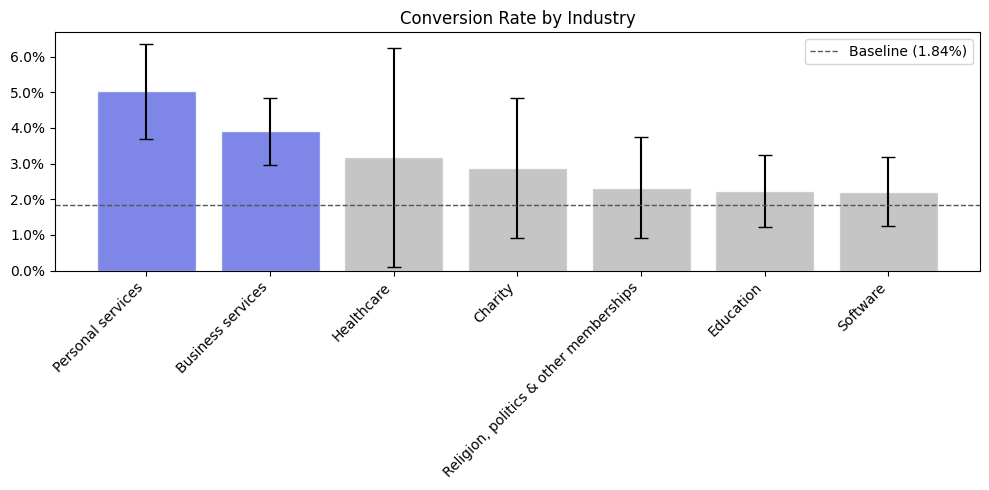

In [20]:
display(industry_segments)
plot_conversion(industry_segments, 'Conversion Rate by Industry', baseline_rate, top_n=10)

### 2b. Business Size

Business size (small / medium / large) is a coarse proxy for operational complexity. If rates are flat across sizes, size is not a useful targeting dimension on its own and should not be included in the scoring model.

In [21]:
%%sql
SELECT
    business_size                               AS segment,
    COUNT(*)                                    AS merchants,
    SUM(converted)                              AS converters,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        - 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        + 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct
FROM master
GROUP BY business_size
HAVING COUNT(*) >= 30
ORDER BY conversion_rate_pct DESC

,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct
0,small,14010,261.0,1.86,1.64,2.09
1,medium,402,5.0,1.24,0.16,2.33
2,large,99,1.0,1.01,-0.96,2.98


### 2c. Country

Geography can be a meaningful predictor — conversion rates may vary by market maturity, local competitor landscape, or how well Stripe's sales team covers a region. Countries with fewer than 30 non-Subscription merchants in the observation window are excluded.

In [22]:
%%sql country_segments <<
SELECT
    country                                     AS segment,
    COUNT(*)                                    AS merchants,
    SUM(converted)                              AS converters,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        - 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        + 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct
FROM master
GROUP BY country
HAVING COUNT(*) >= 30
ORDER BY conversion_rate_pct DESC 
Limit 7

,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct
0,AE,54,6.0,11.11,2.73,19.49
1,JP,253,16.0,6.32,3.32,9.32
2,MX,188,6.0,3.19,0.68,5.70
3,US,4793,132.0,2.75,2.29,3.22
4,CZ,44,1.0,2.27,-2.13,6.68
5,PL,45,1.0,2.22,-2.08,6.53
6,RO,50,1.0,2.00,-1.88,5.88


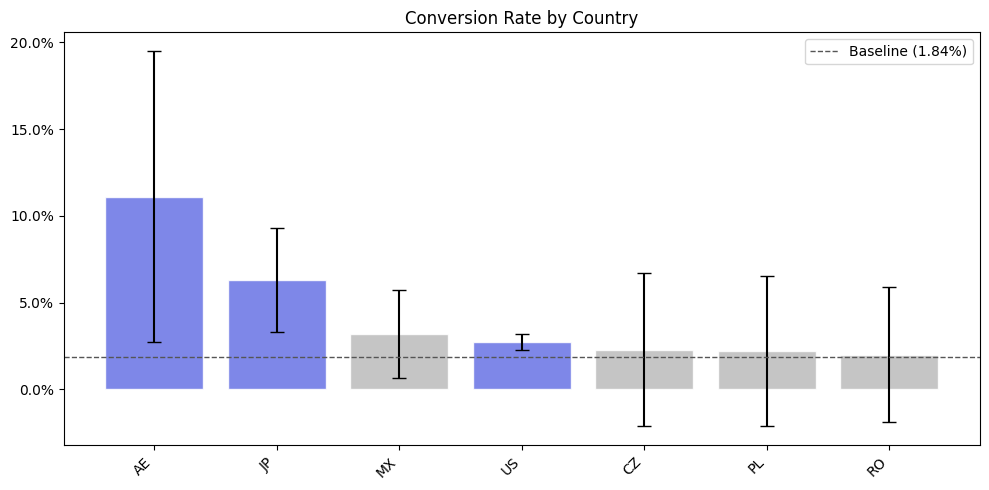

In [23]:
display(country_segments)
plot_conversion(country_segments, 'Conversion Rate by Country', baseline_rate, top_n=10)

### 2d. Average Monthly Volume Quartile

Average monthly volume (excluding zero-volume months) bucketed into quartiles (Q1 = lowest, Q4 = highest). Using avg monthly volume rather than total volume normalizes for tenure — a merchant active for 2 months shouldn't rank below one active for 7 months just because they have less total volume.

Even if rates are flat across quartiles, volume is still useful for *prioritization* (larger merchants = bigger revenue opportunity).

In [24]:
%%sql
SELECT
    'Q' || CAST(q AS VARCHAR)                   AS segment,
    COUNT(*)                                    AS merchants,
    SUM(converted)                              AS converters,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        - 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        + 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct
FROM (
    SELECT converted, NTILE(4) OVER (ORDER BY avg_monthly_vol) AS q FROM master
)
GROUP BY q
HAVING COUNT(*) >= 30
ORDER BY segment

,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct
0,Q1,3628,46.0,1.27,0.90,1.63
1,Q2,3628,66.0,1.82,1.38,2.25
2,Q3,3628,77.0,2.12,1.65,2.59
3,Q4,3627,78.0,2.15,1.68,2.62


### 2e. Dominant Payment Method

The most behaviorally direct signal. A merchant's dominant method reflects how they currently collect payments:

- **checkout** — using Stripe's hosted checkout page; already integrated, switching to Subscriptions is a small step
- **paylink** — using Payment Links (no-code); already on a Stripe-native flow
- **unattributed** — Volume not captured by Checkout or Payment Links or Subscriptions
- **no_volume** — no payment volume in the observation window

In [25]:
%%sql dominant_segments <<
SELECT
    dominant_product                             AS segment,
    COUNT(*)                                    AS merchants,
    SUM(converted)                              AS converters,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        - 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        + 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct
FROM master
GROUP BY dominant_product
HAVING COUNT(*) >= 30
ORDER BY conversion_rate_pct DESC

,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct
0,paylink,667,39.0,5.85,4.07,7.63
1,unattributed,12683,212.0,1.67,1.45,1.89
2,checkout,1161,16.0,1.38,0.71,2.05


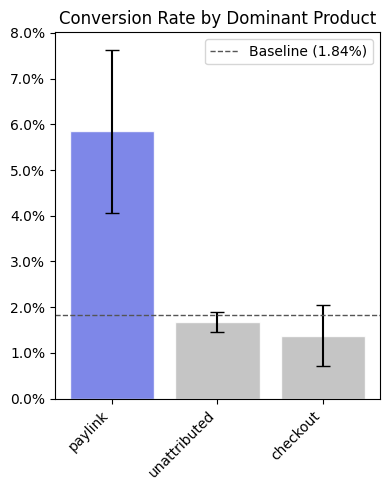

In [26]:
display(dominant_segments)
plot_conversion(dominant_segments, 'Conversion Rate by Dominant Product', baseline_rate, top_n=10, figsize=(4,5))

### 2f. Revenue Consistency (Coefficient of Variation)

CV = `stddev(monthly_volume) / mean(monthly_volume)`. Low CV = stable revenue, high CV = variable/seasonal. Buckets: low (<0.5), medium (0.5–1.0), high (1.0+).

**Note:** Showed very flat conversion rates across all buckets (~0.7–1.2%) — excluded from scoring.

In [27]:
%%sql
SELECT
    CASE
        WHEN revenue_cv IS NULL   THEN 'not enough data' --single month of sales data, not enough to calculate variance across months
        WHEN revenue_cv < 0.5     THEN '1_low_variance (<0.5)'
        WHEN revenue_cv < 1.0     THEN '2_medium_variance (0.5-1.0)'
        ELSE                           '3_high_variance (1.0+)'
    END                                         AS segment,
    COUNT(*)                                    AS merchants,
    SUM(converted)                              AS converters,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        - 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,
    ROUND(100.0 * (SUM(converted) / COUNT(*)
        + 1.96 * SQRT(SUM(converted) / COUNT(*)
        * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct
FROM master
GROUP BY segment
HAVING COUNT(*) >= 30
ORDER BY segment

,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct
0,1_low_variance (<0.5),4343,73.0,1.68,1.30,2.06
1,2_medium_variance (0.5-1.0),4620,89.0,1.93,1.53,2.32
2,3_high_variance (1.0+),1951,44.0,2.26,1.60,2.91
3,not enough data,3597,61.0,1.70,1.27,2.12


### 2g. Merchant Tenure

How long the merchant has been on Stripe as of the end of the observation window. 

**Data quality note:** 26 merchants have `first_charge_date = '0'`. These are treated as NULL and grouped as `unknown`.

In [28]:
%%sql tenure_segments <<
SELECT
      CASE
          WHEN tenure_months IS NULL THEN 'unknown'
          WHEN tenure_months < 2     THEN '<2 months'
          WHEN tenure_months < 12     THEN '2-12 months'
          ELSE                            '12 months+'
      END                                         AS segment,
      COUNT(*)                                    AS merchants,
      SUM(converted)                              AS converters,
      ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct,
      ROUND(100.0 * (SUM(converted) / COUNT(*)
          - 1.96 * SQRT(SUM(converted) / COUNT(*)
          * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_lower_pct,
      ROUND(100.0 * (SUM(converted) / COUNT(*)
          + 1.96 * SQRT(SUM(converted) / COUNT(*)
          * (1 - SUM(converted) / COUNT(*)) / COUNT(*))), 2) AS ci_upper_pct
  FROM master
  GROUP BY segment
  HAVING COUNT(*) >= 30
  ORDER BY segment


,segment,merchants,converters,conversion_rate_pct,ci_lower_pct,ci_upper_pct
0,12 months+,8400,137.0,1.63,1.36,1.90
1,2-12 months,4939,87.0,1.76,1.39,2.13
2,<2 months,1165,43.0,3.69,2.61,4.77


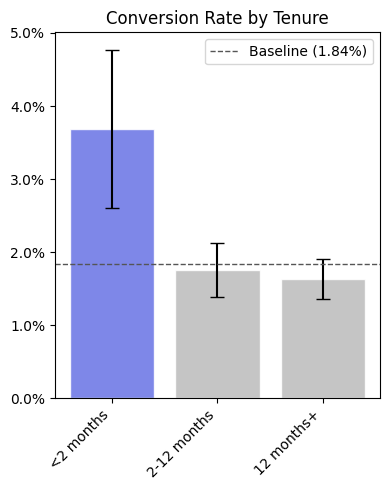

In [29]:

display(tenure_segments)
plot_conversion(tenure_segments, 'Conversion Rate by Tenure', baseline_rate, top_n=10, figsize=(4,5))

## **3. Targeting — CI-Based Segment Filter**

### Approach

Rather than building a score, we use a statistically conservative filter: a merchant is targeted if they fall into at least one segment where the **95% CI lower bound** of the conversion rate is at or above the baseline rate (1.84%).

This means we only act on segments where we are confident — even accounting for sampling uncertainty — that the true conversion rate exceeds the overall average. Merchants in segments that don't clear this bar are not targeted.

**Qualifying segments (ci_lower ≥ 1.84% baseline):**

| Dimension        | Segment                        | Merchants | Converters | Rate   | CI Lower | Baseline | vs Baseline |
|------------------|--------------------------------|-----------|------------|--------|----------|----------|-------------|
| Industry         | Personal services              | 1,016     | 51         | 5.02%  | 3.68%    | 1.84%    | 2.73x       |
| Industry         | Business services              | 1,615     | 63         | 3.90%  | 2.96%    | 1.84%    | 2.12x       |
| Country          | US                             | 4,793     | 132        | 2.75%  | 2.29%    | 1.84%    | 1.49x       |
| Country          | JP                             | 253       | 16         | 6.32%  | 3.32%    | 1.84%    | 3.43x       |
| Country          | AE                             | 54        | 6          | 11.11% | 2.73%    | 1.84%    | 6.04x       |
| Dominant Product | paylink                        | 667       | 39         | 5.85%  | 4.07%    | 1.84%    | 3.18x       |
| **Total**        | **All qualifying**             | -         | -          | **2.99%** | **2.59%** | **1.84%** | **1.63x**   |

The following query was used to compute this summary table ^^

In [30]:
%%sql
  WITH baseline AS (
      SELECT 100.0 * SUM(converted) / COUNT(*) AS rate FROM master
  ),
  segments AS (
      SELECT 'Industry' AS dimension, industry AS segment, COUNT(*) AS merchants,
             SUM(converted) AS converters,
             ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS rate
      FROM master WHERE industry IN ('Personal services','Business services')
      GROUP BY industry
      UNION ALL
      SELECT 'Country', country, COUNT(*), SUM(converted),
             ROUND(100.0 * SUM(converted) / COUNT(*), 2)
      FROM master WHERE country IN ('US','JP','AE')
      GROUP BY country
      UNION ALL
      SELECT 'Dominant Product', dominant_product, COUNT(*), SUM(converted),
             ROUND(100.0 * SUM(converted) / COUNT(*), 2)
      FROM master WHERE dominant_product = 'paylink'
      GROUP BY dominant_product
  ),
  totals AS (
      SELECT 'Total' AS dimension, 'All qualifying' AS segment,
             null AS merchants,
             null AS converters,
             ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS rate
      FROM master
      WHERE industry IN ('Personal services','Business services')
         OR country IN ('US','JP','AE')
         OR dominant_product = 'paylink'
  )
  SELECT
      s.dimension,
      s.segment,
      s.merchants,
      s.converters,
      s.rate                                                                          AS rate,
      ROUND(100.0 * (s.rate/100 - 1.96 * SQRT(s.rate/100 * (1-s.rate/100) / s.merchants)), 2) AS ci_lower,
      ROUND(b.rate, 2)                                                                AS baseline,
      ROUND(s.rate / b.rate, 2) || 'x'                                               AS vs_baseline
  FROM segments s CROSS JOIN baseline b
  UNION ALL
  SELECT
      t.dimension, t.segment, t.merchants, t.converters,
      t.rate,
      ROUND(100.0 * (t.rate/100 - 1.96 * SQRT(t.rate/100 * (1-t.rate/100) / t.merchants)), 2),
      ROUND(b.rate, 2),
      ROUND(t.rate / b.rate, 2) || 'x'
  FROM totals t CROSS JOIN baseline b
  ORDER BY dimension, rate DESC

,dimension,segment,merchants,converters,rate,ci_lower,baseline,vs_baseline
0,Country,AE,54,6.0,11.11,2.73,1.84,6.04x
1,Country,JP,253,16.0,6.32,3.32,1.84,3.43x
2,Country,US,4793,132.0,2.75,2.29,1.84,1.49x
3,Dominant Product,paylink,667,39.0,5.85,4.07,1.84,3.18x
4,Industry,Personal services,1016,51.0,5.02,3.68,1.84,2.73x
5,Industry,Business services,1615,63.0,3.90,2.96,1.84,2.12x
6,Total,All qualifying,<NA>,NaN,2.99,NaN,1.84,1.63x


### Generate Target list
We need to recompute the features (avg monthly vol, dominant product etc.) over the entire history rather than on the observation period. Then we filter for the qualifying segments.


In [31]:
%%sql
  CREATE OR REPLACE VIEW targets AS                                                                                                                                                                          
  WITH
  subscribers AS (
      SELECT DISTINCT merchant
      FROM payments
      WHERE subscription_volume > 0
  ),
  features AS (
      SELECT
          mm.merchant, mm.industry, mm.country, mm.business_size, mm.first_charge_date,
          SUM(mm.checkout_vol)                                                     AS total_checkout_vol,
          SUM(mm.paylink_vol)                                                      AS total_paylink_vol,
          SUM(mm.total_vol)                                                        AS total_vol,
          AVG(mm.total_vol)                                                        AS avg_monthly_vol,
          CASE
            WHEN SUM(mm.checkout_vol) > SUM(mm.paylink_vol)
             AND SUM(mm.checkout_vol) > SUM(mm.unattributed_vol) THEN 'checkout'
            WHEN SUM(mm.paylink_vol)  > SUM(mm.unattributed_vol) THEN 'paylink'
            WHEN SUM(mm.unattributed_vol) > 0                    THEN 'unattributed'
            ELSE NULL
          END                                                                      AS dominant_product,
          DATEDIFF('month', mm.first_charge_date, DATE '2041-11-30')               AS tenure_months
      FROM merchant_monthly mm
      LEFT JOIN subscribers s USING (merchant)
      WHERE s.merchant IS NULL
      GROUP BY mm.merchant, mm.industry, mm.country, mm.business_size, mm.first_charge_date
  )
  SELECT
      f.merchant, f.industry, f.business_size, f.country, f.dominant_product,
      f.total_checkout_vol                                                         AS checkout_usd,
      f.total_paylink_vol                                                          AS paylink_usd,
      f.total_vol                                                                  AS total_usd,
      f.avg_monthly_vol                                                                AS avg_monthly_vol,
      f.tenure_months,
      CASE WHEN f.industry IN ('Personal services','Business services') THEN 1 ELSE 0 END AS flag_industry,
      CASE WHEN f.country   IN ('US','JP','AE')                         THEN 1 ELSE 0 END AS flag_country,
      CASE WHEN f.dominant_product = 'paylink'                           THEN 1 ELSE 0 END AS flag_product
  FROM features f
  JOIN merchants mer USING (merchant)
  WHERE (f.industry IN ('Personal services','Business services')
     OR f.country   IN ('US','JP','AE')
     OR f.dominant_product = 'paylink'
    ) and tenure_months>=2
    
;
select * from targets limit 5

,merchant,industry,business_size,country,dominant_product,checkout_usd,paylink_usd,total_usd,avg_monthly_vol,tenure_months,flag_industry,flag_country,flag_product
0,a8d01667,Digital goods,small,US,unattributed,0.0,0.00,9362.99,851.180909,48,0,1,0
1,594db93a,Merchandise,small,US,unattributed,0.0,0.00,912.00,114.000000,39,0,1,0
2,97d120bc,Personal services,small,US,unattributed,0.0,0.00,34089.80,5681.633333,5,1,1,0
3,49649d53,Personal services,small,IT,paylink,0.0,76549.69,110324.86,11032.486000,2,1,0,1
4,b708486a,Travel & lodging,small,US,unattributed,0.0,0.00,543137.50,77591.071429,18,0,1,0


In [32]:
%%sql
  SELECT * FROM (
      SELECT 'Industry' AS dimension, industry AS segment, COUNT(*) AS merchants
      FROM targets WHERE flag_industry = 1
      GROUP BY industry
      UNION ALL
      SELECT 'Country', country, COUNT(*)
      FROM targets WHERE flag_country = 1
      GROUP BY country
      UNION ALL
      SELECT 'Dominant Product', dominant_product, COUNT(*)
      FROM targets WHERE flag_product = 1
      GROUP BY dominant_product
      UNION ALL
      SELECT 'Total', 'All qualifying', COUNT(*)
      FROM targets
  )
  ORDER BY
      CASE dimension WHEN 'Industry' THEN 1 WHEN 'Country' THEN 2 WHEN 'Dominant Product' THEN 3 ELSE 4 END,
      merchants DESC

,dimension,segment,merchants
0,Industry,Business services,1580
1,Industry,Personal services,987
2,Country,US,4801
3,Country,JP,230
4,Country,AE,36
5,Dominant Product,paylink,661
6,Total,All qualifying,6769


### Prioritize Based on Volume
My strategy is to take the merchants with highest volume and recommend them for direct sales outreach. Here I am segmenting merchants into deciles based on monthly volume to decide what portion of merchants should get the direct sales outreach. The top decile makes up +90% of the revenue opportunity and is only 679 merchants so this is a tractable segment for a direct sales outreach that has great impact potential.

In [33]:
%%sql
  WITH deciles AS (
      SELECT avg_monthly_vol,
             NTILE(10) OVER (ORDER BY avg_monthly_vol) AS decile
      FROM targets
  ),
  by_decile AS (
      SELECT
          decile,
          COUNT(*)                                                             AS merchants,
          ROUND(SUM(avg_monthly_vol), 0)                                      AS total_monthly_vol,
          ROUND(100.0 * SUM(avg_monthly_vol) / SUM(SUM(avg_monthly_vol)) OVER (), 1) AS pct_of_total_vol
      FROM deciles
      GROUP BY decile
  )
  SELECT
      decile,
      merchants,
      total_monthly_vol,
      pct_of_total_vol,
      ROUND(SUM(pct_of_total_vol) OVER (ORDER BY decile DESC), 1) AS cumulative_pct
  FROM by_decile
  ORDER BY decile DESC

,decile,merchants,total_monthly_vol,pct_of_total_vol,cumulative_pct
0,10,676,91521878.0,90.5,90.5
1,9,677,4817883.0,4.8,95.3
2,8,677,2160386.0,2.1,97.4
3,7,677,1196149.0,1.2,98.6
4,6,677,675438.0,0.7,99.3
5,5,677,377749.0,0.4,99.7
6,4,677,204629.0,0.2,99.9
7,3,677,100994.0,0.1,100.0
8,2,677,41266.0,0.0,100.0
9,1,677,8153.0,0.0,100.0


## Tiers
- **Tier 1: Direct Sales Outreach** - top 10% by avg monthly volume among qualifying merchants
- **Tier 2: Digital campaign** - remaining qualifying merchants
- **Tier 3: Non-qualifying** - segments below CI threshold 

In [34]:
%%sql
CREATE OR REPLACE VIEW targets_tiered AS
  WITH vol_cutoff AS (
      SELECT PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY avg_monthly_vol) AS p90
      FROM targets
  )
  SELECT
      t.*,
      CASE
          WHEN t.avg_monthly_vol >= v.p90 THEN 'Tier 1: Direct Sales Outreach'
          WHEN (flag_industry + flag_country + flag_product) >= 2 THEN 'Tier 2: Digital Marketing'
          ELSE 'Doesnt Qualify'
      END AS tier
  FROM targets t
  CROSS JOIN vol_cutoff v
    where tier<>'Doesnt Qualify'
  ORDER BY tier, t.avg_monthly_vol DESC
;
select * from targets_tiered limit 5

,merchant,industry,business_size,country,dominant_product,checkout_usd,paylink_usd,total_usd,avg_monthly_vol,tenure_months,flag_industry,flag_country,flag_product,tier
0,dbb42c22,Clothing & accessory,large,US,unattributed,0.00,0.0,99255611.33,9.023237e+06,3,0,1,0,Tier 1: Direct Sales Outreach
1,0a97fe33,Furnishing,medium,US,unattributed,0.00,0.0,98459619.91,6.563975e+06,63,0,1,0,Tier 1: Direct Sales Outreach
2,f533c70f,Cosmetics,large,US,unattributed,0.00,0.0,97831457.84,6.522097e+06,19,0,1,0,Tier 1: Direct Sales Outreach
3,29c10133,Business services,medium,FR,unattributed,4927074.52,0.0,55080150.83,3.672010e+06,11,1,0,0,Tier 1: Direct Sales Outreach
4,81c3d402,Others,medium,US,unattributed,0.00,0.0,41798314.49,2.786554e+06,38,0,1,0,Tier 1: Direct Sales Outreach


## 6. Export

Write `targets.csv` — one row per merchant, all tiers included. The `tier` column allows a sales team to filter directly in Excel. Tier 3 rows are included so the file is the complete non-Subscription merchant universe, not just the targeted subset.

Also write `segment_conversion_rates.csv` — the raw segment analysis for documentation and audit.

In [35]:
  from sql.connection import ConnectionManager
  from sqlalchemy import text                                                                                                                                                                                                 
   
  con = ConnectionManager.current._connection                                                                                                                                                                                 
                                                               
  # Export targets.csv
  con.execute(text("COPY (SELECT * FROM targets_tiered) TO 'targets.csv' (HEADER, DELIMITER ',')"))
  print('targets.csv written')                                                                                                                                                                                                
   

targets.csv written
